In [ ]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [7]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [69]:
import pandas as pd
import numpy as np
from sklearn import tree # module for decision tree algorithms
from sklearn.model_selection import train_test_split # module for splitting data into training and testing sets
from sklearn.tree import DecisionTreeClassifier # class for creating a decision tree classifier
from sklearn.ensemble import RandomForestClassifier  

from sklearn.tree import export_graphviz # function for exporting decision tree in DOT format
from sklearn.metrics import accuracy_score # function for calculating accuracy score
from sklearn.metrics import confusion_matrix # function for calculating confusion matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score


In [ ]:
pd1 = pd.read_csv('..\\data\\True.csv')
pd1['label'] = '0'
pd2 = pd.read_csv('..\\data\\Fake.csv')
pd2['label'] = '1'

file=pd.concat([pd1, pd2], ignore_index=True)
file.head()
# file.info()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",0


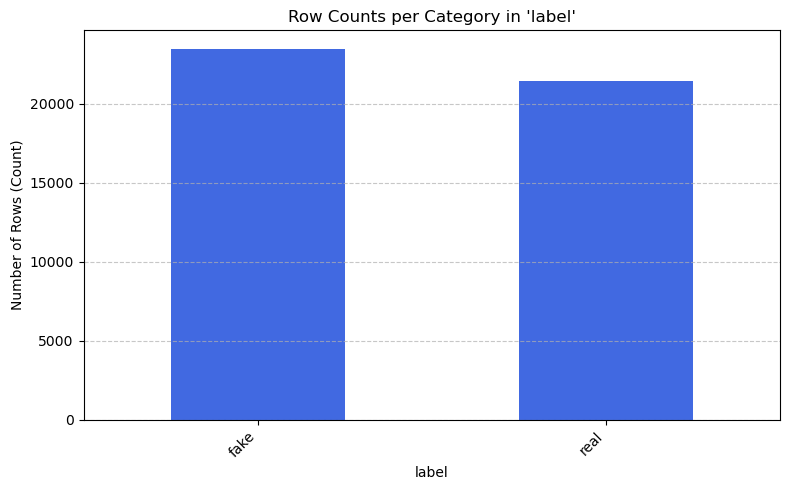

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

counts = file['label'].value_counts()

# 4. Generate the graph
fig, ax = plt.subplots(figsize=(8, 5))
counts.plot(kind='bar', color='royalblue', ax=ax)

# 5. Customize the graph labels
ax.set_title(f"Row Counts per Category in 'label'")
ax.set_xlabel("label")
ax.set_ylabel("Number of Rows (Count)")
plt.xticks(rotation=45, ha='right')  # Tilts text labels so they do not overlap
ax.grid(axis='y', linestyle='--', alpha=0.7)  # Adds clean horizontal gridlines

# 6. Render the final plot
plt.tight_layout()  # Prevents labels from getting cut off at the margins
plt.show()

In [62]:
# Split dataset into training set and test set
# Use X and y from the dataset
# X = file.drop('label', axis=1)  # Features (all columns except 'label')
# print(X)
X = file['title']
y = file['label']  # Target variable (the 'label' column)
print(y.shape)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)  
# print("Features (X):")
display(X.head())

print("\nTarget (y):")
display(y.head())                     # 70% training and 30% test

(44898,)


0    As U.S. budget fight looms, Republicans flip t...
1    U.S. military to accept transgender recruits o...
2    Senior U.S. Republican senator: 'Let Mr. Muell...
3    FBI Russia probe helped by Australian diplomat...
4    Trump wants Postal Service to charge 'much mor...
Name: title, dtype: object


Target (y):


0    0
1    0
2    0
3    0
4    0
Name: label, dtype: object

In [63]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=500)
X_train_tfidf = vectorizer.fit_transform(X_train)
print(X_train_tfidf)
# 
# y_train_tfidf = vectorizer.fit_transform(y_train)
# print(y_train_tfidf)
# y_test_tfidf = vectorizer.transform(y_test)
# print(y_test_tfidf)


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 131156 stored elements and shape (31428, 500)>
  Coords	Values
  (1, 450)	0.31294825560682127
  (1, 201)	0.9497701771021492
  (2, 398)	0.5510612434586442
  (2, 187)	0.3498491482145028
  (2, 254)	0.5483612076729355
  (2, 322)	0.5227208292873735
  (3, 252)	0.6765231022712211
  (3, 315)	0.5658912554474886
  (3, 219)	0.47125744461110447
  (4, 62)	0.4836206599873242
  (4, 210)	0.6285357157972481
  (4, 442)	0.6091419466763603
  (5, 290)	0.35787681100388585
  (5, 323)	0.493261346805309
  (5, 81)	0.35726118596228756
  (5, 420)	0.4860622613188606
  (5, 471)	0.5145146791102438
  (6, 450)	0.20303404317859644
  (6, 476)	0.5399878048757539
  (6, 491)	0.5234941929357473
  (6, 246)	0.6270121034386554
  (7, 297)	0.4239006395431597
  (7, 131)	0.5551431641788493
  (7, 171)	0.715628615316908
  (8, 315)	0.3098881350067819
  :	:
  (31421, 390)	0.3650876463149373
  (31421, 82)	0.40305988181217206
  (31422, 450)	0.22194385749768927
  (31422, 323)	

In [72]:
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train_tfidf, y_train)

X_test_tfidf = vectorizer.transform(X_test)
# print(X_test_tfidf)
# 5. Evaluate the model performance
predictions = model.predict(X_test_tfidf)
print(f"Model Precision Accuracy: {accuracy_score(y_test, predictions) * 100}%")
# print(classification_report(y_test, predictions, target_names=['Real News', 'Fake News']))

Model Precision Accuracy: 73.19227913882702%


In [73]:
# 5. Extract Confusion Matrix Quadrants
# .ravel() flattens the 2x2 matrix grid into 4 separate scalar variables
tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()

# 6. Calculate All Target Metrics
precision = precision_score(y_test, predictions, pos_label='1')
recall = recall_score(y_test, predictions, pos_label='1')
f1 = f1_score(y_test, predictions, pos_label='1')

# 7. Print Results Layout
print("--- Confusion Matrix Breakdown ---")
print(f"True Negatives  (TN - Clean Cleared):  {tn}")
print(f"False Positives (FP - Clean Flagged):  {fp}")
print(f"False Negatives (FN - Fake Missed):    {fn}")
print(f"True Positives  (TP - Fake Caught):    {tp}\n")

print("--- Performance Scores ---")
print(f"Precision Score : {precision:.2%}")
print(f"Recall Score    : {recall:.2%}")
print(f"F1-Score        : {f1:.2%}")

--- Confusion Matrix Breakdown ---
True Negatives  (TN - Clean Cleared):  6425
False Positives (FP - Clean Flagged):  37
False Negatives (FN - Fake Missed):    3574
True Positives  (TP - Fake Caught):    3434

--- Performance Scores ---
Precision Score : 98.93%
Recall Score    : 49.00%
F1-Score        : 65.54%


In [66]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)

# 3. Predict safely
predictions = rf_model.predict(X_test_tfidf)
print(f"Random Forest Performance Accuracy: {accuracy_score(y_test, predictions) * 100}%")

Random Forest Performance Accuracy: 90.14847809948033%


In [71]:
# 5. Extract Confusion Matrix Quadrants
# .ravel() flattens the 2x2 matrix grid into 4 separate scalar variables
tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()

# 6. Calculate All Target Metrics
precision = precision_score(y_test, predictions, pos_label='1')
recall = recall_score(y_test, predictions, pos_label='1')
f1 = f1_score(y_test, predictions, pos_label='1')

# 7. Print Results Layout
print("--- Confusion Matrix Breakdown ---")
print(f"True Negatives  (TN - Clean Cleared):  {tn}")
print(f"False Positives (FP - Clean Flagged):  {fp}")
print(f"False Negatives (FN - Fake Missed):    {fn}")
print(f"True Positives  (TP - Fake Caught):    {tp}\n")

print("--- Performance Scores ---")
print(f"Precision Score : {precision:.2%}")
print(f"Recall Score    : {recall:.2%}")
print(f"F1-Score        : {f1:.2%}")

--- Confusion Matrix Breakdown ---
True Negatives  (TN - Clean Cleared):  5859
False Positives (FP - Clean Flagged):  603
False Negatives (FN - Fake Missed):    724
True Positives  (TP - Fake Caught):    6284

--- Performance Scores ---
Precision Score : 91.24%
Recall Score    : 89.67%
F1-Score        : 90.45%
